# Анализ отзывов Yelp (EDA_2)

здесь мы разбираем срез данных Yelp под две задачи. первая - предсказать оценку которую пользователь поставит заведению, по табличным признакам. вторая - анализ текста отзывов: тональность, аспекты, расхождение текста и оценки.

нужно понять как кодировать признаки, какие модели брать и какие проблемы придется чинить перед обучением

срез городов выбран в EDA_1, данные готовят скрипты download.py и preprocess.py.

In [1]:
import sys
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(root))
from _constants import BUSINESS_PARQUET, REVIEWS_PARQUET, USERS_PARQUET, TIPS_PARQUET, META_PARQUET

In [3]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## Загрузка среза
грузим подготовленные parquet-таблицы. срез это несколько выбранных городов, он целиком влезает в память.

In [4]:
business = pd.read_parquet(BUSINESS_PARQUET)
reviews = pd.read_parquet(REVIEWS_PARQUET)
users = pd.read_parquet(USERS_PARQUET)
tips = pd.read_parquet(TIPS_PARQUET) if TIPS_PARQUET.exists() else pd.DataFrame()
meta = pd.read_parquet(META_PARQUET)
CITY = meta.loc[0, "cities"]
reviews["date"] = pd.to_datetime(reviews["date"], errors="coerce")
print(CITY)
print(len(business), len(reviews), len(users), len(tips))

Tucson, AZ + St Petersburg, FL + Edmonton, AB
17556 664751 209093 91803


это срез из нескольких городов: заведения, отзывы, юзеры и типсы. отзывы самая большая таблица, на ней всё и строится.

## Обзор датасета
масштаб, период и динамика - общий контекст для обеих задач.

In [ ]:
n_users = reviews["user_id"].nunique()
n_biz = reviews["business_id"].nunique()
span = (reviews["date"].min(), reviews["date"].max())
overview = pd.DataFrame({
    "Метрика": ["Города среза", "Заведений (в срезе)", "Заведений с отзывами",
                "Уникальных юзеров", "Отзывов", "Типсов (без оценки)",
                "Период отзывов", "Средняя оценка"],
    "Значение": [CITY, f"{len(business):,}", f"{n_biz:,}",
                 f"{n_users:,}", f"{len(reviews):,}", f"{len(tips):,}",
                 f"{span[0].date()} - {span[1].date()}",
                 f"{reviews['stars'].mean():.2f}"],
})
overview

,Метрика,Значение
0,Города среза,"Tucson, AZ + St Petersburg, FL + Edmonton, AB"
1,Заведений (в срезе),"17,556"
2,Заведений с отзывами,"17,556"
3,Уникальных юзеров,"209,098"
4,Отзывов,"664,751"
5,Типсов (без оценки),"91,803"
6,Период отзывов,2005-03-02 - 2022-01-19
7,Средняя оценка,3.72


в срезе около 17 тысяч заведений и сотни тысяч отзывов за несколько лет. данных хватает и для рекомендателя и для анализа текста.

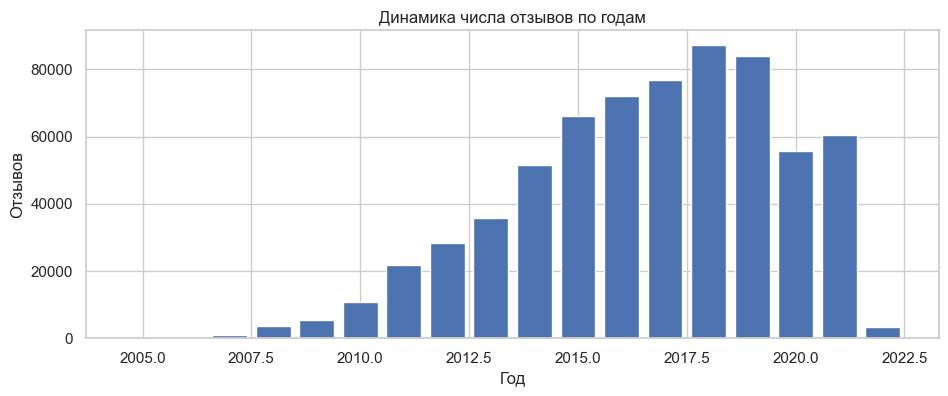

In [6]:
by_year = reviews.set_index("date").resample("YE").size()
plt.figure(figsize=(11,4))
plt.bar(by_year.index.year, by_year.values)
plt.title("Динамика числа отзывов по годам")
plt.xlabel("Год")
plt.ylabel("Отзывов")
plt.show()

число отзывов почти каждый год растёт, основная масса данных приходится на последние годы среза.

## EDA для задачи 1

рекомендатель учится по тройкам user, business, stars. смотрим распределение таргета, активность юзеров и популярность мест, разреженность матрицы и смещения оценок

### Распределение таргета stars
посмотрим как распределены оценки в отзывах и средние оценки заведений

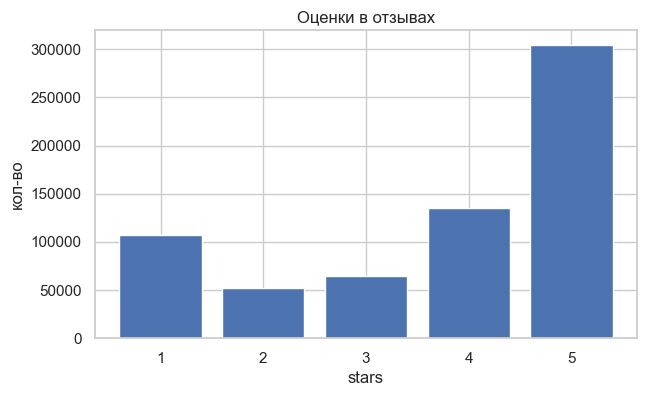

In [7]:
vc = reviews["stars"].value_counts().sort_index()
plt.figure(figsize=(7,4))
plt.bar(vc.index, vc.values)
plt.title("Оценки в отзывах")
plt.xlabel("stars")
plt.ylabel("кол-во")
plt.show()

оценок 4 и 5 заметно больше всего, классы несбалансированы. для рекомендателя accuracy может давать ложные результаты, смотрим на RMSE и MAE

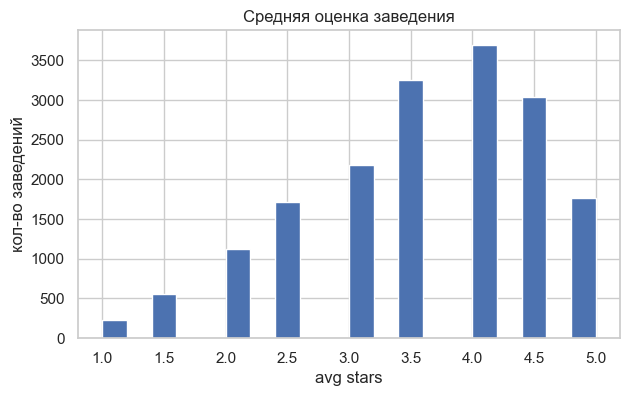

In [8]:
plt.figure(figsize=(7,4))
plt.hist(business["stars"], bins=20)
plt.title("Средняя оценка заведения")
plt.xlabel("avg stars")
plt.ylabel("кол-во заведений")
plt.show()

средние оценки заведений тоже смещены вправо, большинство держится в районе 3.5-4.5.

### Активность юзеров и cold-start

In [9]:
ru = reviews.groupby("user_id").size()
rb = reviews.groupby("business_id").size()

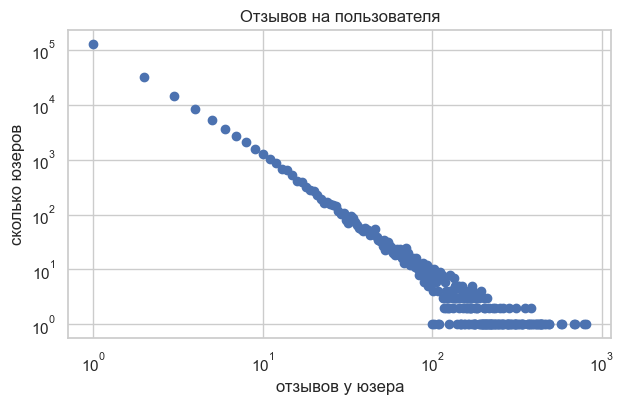

In [10]:
vc = ru.value_counts().sort_index()
plt.figure(figsize=(7,4))
plt.scatter(vc.index, vc.values)
plt.xscale("log")
plt.yscale("log")
plt.title("Отзывов на пользователя")
plt.xlabel("отзывов у юзера")
plt.ylabel("сколько юзеров")
plt.show()

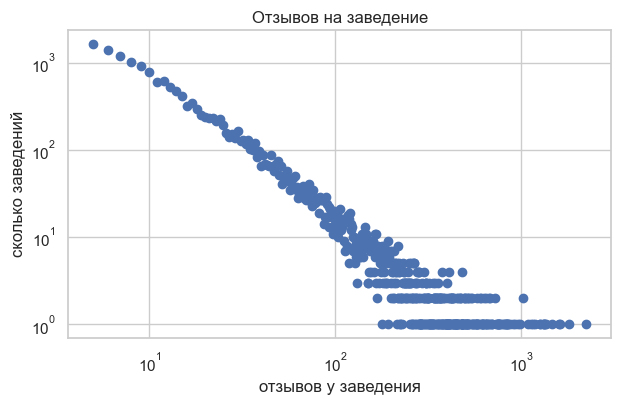

In [11]:
vc = rb.value_counts().sort_index()
plt.figure(figsize=(7,4))
plt.scatter(vc.index, vc.values)
plt.xscale("log")
plt.yscale("log")
plt.title("Отзывов на заведение")
plt.xlabel("отзывов у заведения")
plt.ylabel("сколько заведений")
plt.show()

In [12]:
cold_u = (ru == 1).mean()
cold_b = (rb == 1).mean()
cold_u, cold_b

(np.float64(0.6100058345847401), np.float64(0.0))

и у юзеров и у заведений активность это степенной хвост, большинство с одним-двумя отзывами а верхушка дает основную долю. отсюда холодный старт и разреженность.

### Разреженность матрицы взаимодействий
считаем плотность матрицы users x businesses и насколько неравномерно отзывы распределены по заведениям.

In [13]:
n_u = reviews["user_id"].nunique()
n_b = reviews["business_id"].nunique()
density = len(reviews) / (n_u * n_b)
top10 = rb.sort_values(ascending=False).head(int(n_b * 0.1)).sum() / len(reviews)
density, top10

(0.00018108544650619356, np.float64(0.554594126221698))

матрица user x business заполнена на доли процента, и топ 10% заведений собирают основную часть отзывов. отсюда сильная разреженность и предпочтение за обучаемые эмбеддинги вместо one-hot

### Смещения оценок
юзеры бывают добрее или строже среднего, заведения лучше или хуже. разброс смещений показывает сколько даст простой baseline mu + b_user + b_item.

In [14]:
mu = reviews["stars"].mean()
ub = reviews.groupby("user_id")["stars"].mean() - mu
bb = reviews.groupby("business_id")["stars"].mean() - mu

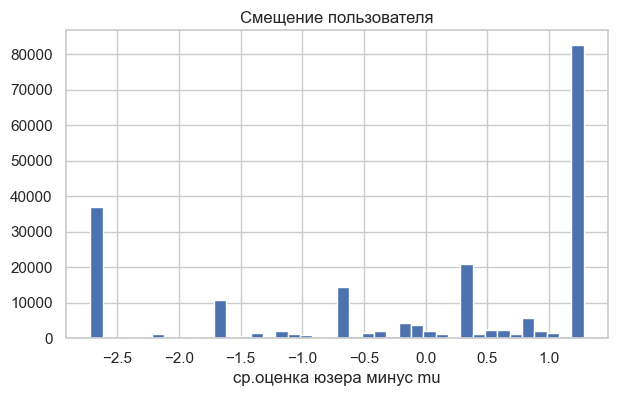

In [15]:
plt.figure(figsize=(7,4))
plt.hist(ub, bins=40)
plt.title("Смещение пользователя")
plt.xlabel("ср.оценка юзера минус mu")
plt.show()

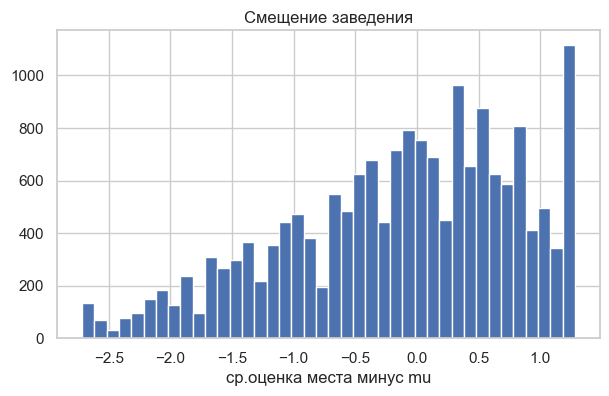

In [16]:
plt.figure(figsize=(7,4))
plt.hist(bb, bins=40)
plt.title("Смещение заведения")
plt.xlabel("ср.оценка места минус mu")
plt.show()

In [17]:
ub.std(), bb.std()

(np.float64(1.5175672086368672), np.float64(0.9485265500073042))

у юзеров и заведений заметный разброс смещений, кто-то систематически добрее или строже. значит baseline mu + b_user + b_item уже даёт приличную точность, в матричной факторизации эти термы нужны.

### Признаки заведений и связь с оценкой
категории, цена и популярность могут быть полезны во входные фичи. смотрим что из этого связано с оценкой.

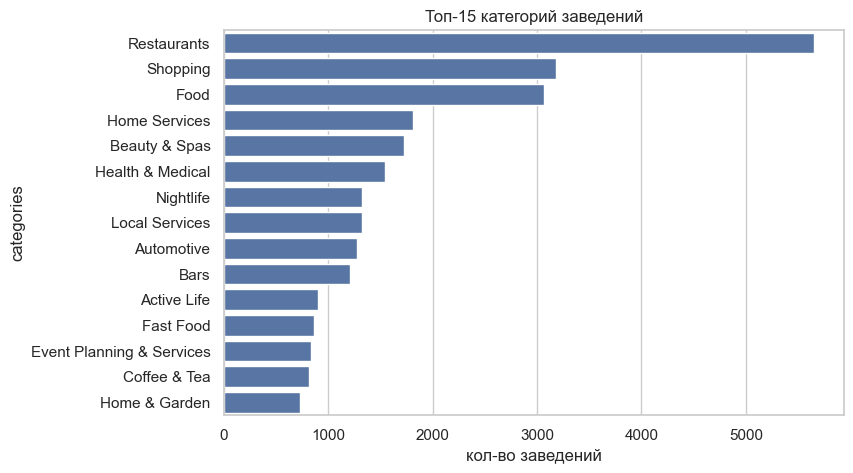

In [18]:
cats = business["categories"].dropna().str.split(", ").explode()
top_cats = cats.value_counts().head(15)
plt.figure(figsize=(8,5))
sns.barplot(x=top_cats.values, y=top_cats.index)
plt.title("Топ-15 категорий заведений")
plt.xlabel("кол-во заведений")
plt.show()

в срезе преобладают рестораны, кафе и бары, категории сильно пересекаются. это кандидат в признаки заведения.

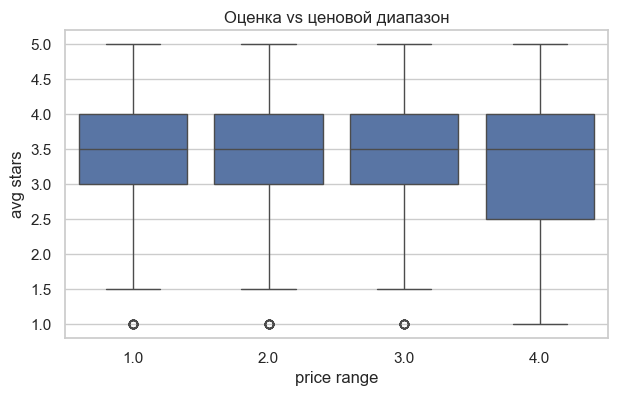

In [19]:
pr = business.dropna(subset=["price_range"])
plt.figure(figsize=(7,4))
sns.boxplot(data=pr, x="price_range", y="stars")
plt.title("Оценка vs ценовой диапазон")
plt.xlabel("price range")
plt.ylabel("avg stars")
plt.show()

разброс оценок по ценовым категориям небольшой, сильной связи цены и оценки не видно

In [20]:
num = reviews[["stars", "useful", "funny", "cool"]]
num.corr()["stars"].round(3)

stars     1.000
useful   -0.116
funny    -0.065
cool      0.093
Name: stars, dtype: float64

голоса useful/funny/cool почти не коррелируют с оценкой отзыва, как признаки для предсказания оценки они слабые.

## Текстовый EDA для задачи 2

дальше смотрим на сам текст. интересует длина отзывов, баланс тональности, словарь, какие слова отличают хорошие отзывы от плохих, аспекты, расхождение текста с оценкой и язык.

### Длина отзывов
она задаёт max_len и стоимость обучения. длинные хвосты режем по перцентилю а не по максимуму.

In [21]:
reviews["n_words"] = reviews["text"].str.split().map(len)

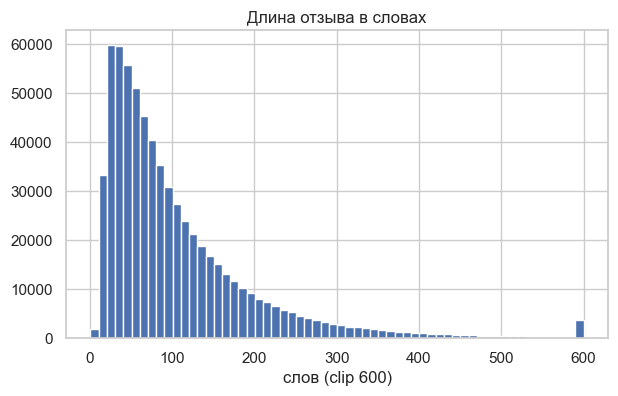

In [22]:
plt.figure(figsize=(7,4))
plt.hist(reviews["n_words"].clip(upper=600), bins=60)
plt.title("Длина отзыва в словах")
plt.xlabel("слов (clip 600)")
plt.show()

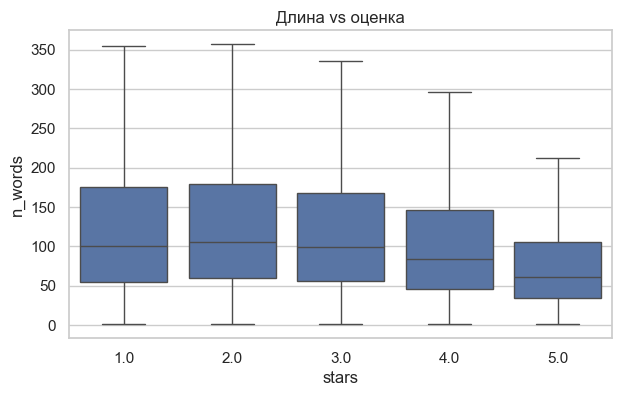

In [23]:
plt.figure(figsize=(7,4))
sns.boxplot(data=reviews, x="stars", y="n_words", showfliers=False)
plt.title("Длина vs оценка")
plt.show()

In [24]:
reviews["n_words"].quantile([0.5, 0.9, 0.95, 0.99]).round()

0.50     77.0
0.90    223.0
0.95    296.0
0.99    501.0
Name: n_words, dtype: float64

медиана длины небольшая, но хвост длинный. по 95 перцентилю берём max_len, остальное обрезаем.

### Баланс классов тональности
из stars делаем метку: 1-2 negative, 3 neutral, 4-5 positive. дисбаланс это повод для class weights.

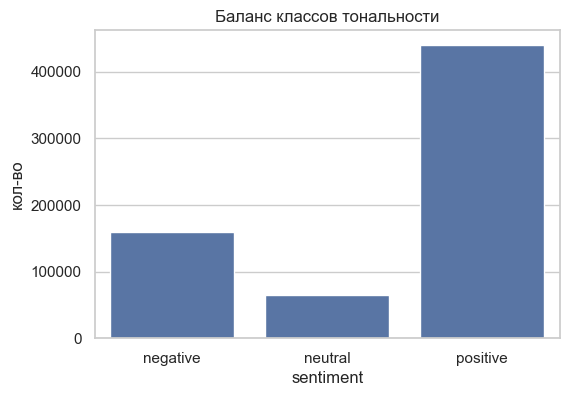

In [25]:
def to_sentiment(s):
    return np.where(s<=2, "negative", np.where(s==3, "neutral", "positive"))
reviews["sentiment"] = to_sentiment(reviews["stars"])
bal = reviews["sentiment"].value_counts().reindex(["negative", "neutral", "positive"])
plt.figure(figsize=(6,4))
sns.barplot(x=bal.index, y=bal.values)
plt.title("Баланс классов тональности")
plt.ylabel("кол-во")
plt.show()

классы сильно несбалансированы, позитивных большинство. при обучении нужны class weights и macro-F1, а не accuracy.

### Словарь и отличительные слова
размер словаря задаёт размер эмбеддинг-слоя. чтобы понять какие слова отличают хорошие отзывы от плохих, сравним частоту слов в позитивных и негативных.

In [26]:
from sklearn.feature_extraction.text import CountVectorizer
samp = reviews.sample(150000, random_state=42)
vec = CountVectorizer(stop_words="english", min_df=20)
X = vec.fit_transform(samp["text"].fillna(""))
vocab = vec.get_feature_names_out()
len(vocab)

13928

словарь получился в районе нескольких тысяч слов, примерно столько и заложим в эмбеддинг-слой.

In [27]:
pos = np.asarray(X[(samp["sentiment"] == "positive").values].sum(axis=0)).ravel()
neg = np.asarray(X[(samp["sentiment"] == "negative").values].sum(axis=0)).ravel()
diff = pos / pos.sum() - neg / neg.sum()
words = pd.Series(diff, index=vocab).sort_values()
words.tail(15)

awesome       0.001945
recommend     0.001976
excellent     0.001993
tucson        0.001994
fresh         0.002117
nice          0.002496
definitely    0.003002
place         0.003455
best          0.003712
amazing       0.003735
friendly      0.003872
love          0.003959
delicious     0.004161
good          0.005122
great         0.010641
dtype: float64

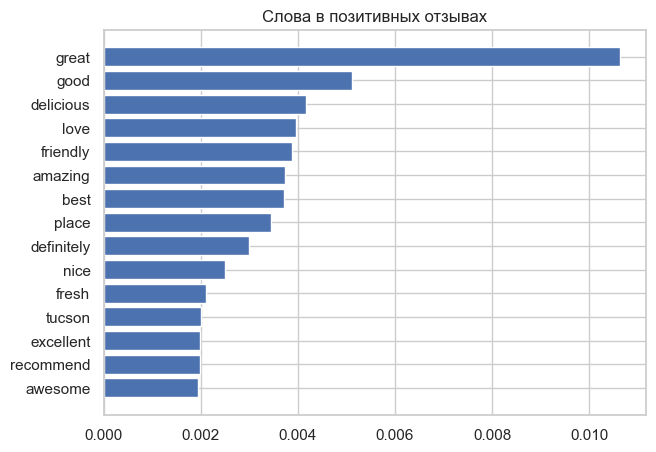

In [28]:
top = words.tail(15)
plt.figure(figsize=(7,5))
plt.barh(top.index, top.values)
plt.title("Слова в позитивных отзывах")
plt.show()

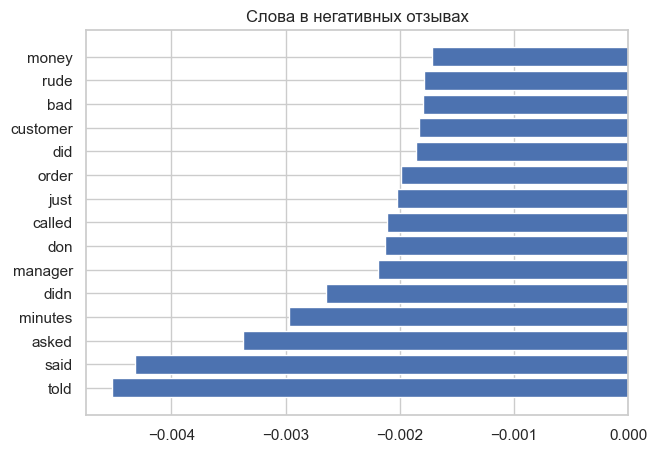

In [29]:
top = words.head(15)
plt.figure(figsize=(7,5))
plt.barh(top.index, top.values)
plt.title("Слова в негативных отзывах")
plt.show()

позитивные и негативные отзывы используют заметно разные слова, даже простое сравнение частот хорошо их разделяет. значит текст несёт сильный сигнал для модели.

### Аспекты: food / service / price
проверяем что аспектные слова реально встречаются и по-разному ведут себя в хороших и плохих отзывах.

In [30]:
ASPECTS = {
    "food": r"\b(food|dish|meal|taste|flavor|menu|portion|delicious|pizza|burger|chicken)\b",
    "service": r"\b(service|staff|waiter|waitress|server|manager|rude|friendly|attentive)\b",
    "price": r"\b(price|cheap|expensive|value|worth|overpriced|affordable|cost)\b",
    "ambience": r"\b(ambience|atmosphere|decor|music|cozy|noisy|clean|seating)\b",
}
asp = samp.copy()
for a, pat in ASPECTS.items():
    asp[a] = asp["text"].str.contains(pat, case=False, regex=True, na=False)
share = asp[list(ASPECTS)].mean().sort_values(ascending=False)
by_asp = pd.DataFrame({a: [asp.loc[asp[a], "stars"].mean(), asp[a].mean()] for a in ASPECTS},
                      index=["avg_stars", "share"]).T
by_asp.round(3)

,avg_stars,share
food,3.791,0.523
service,3.669,0.510
price,3.571,0.179
ambience,4.011,0.187


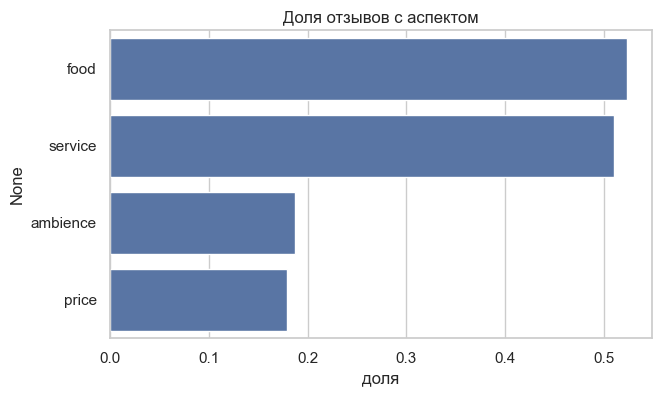

In [31]:
plt.figure(figsize=(7,4))
sns.barplot(x=share.values, y=share.index)
plt.title("Доля отзывов с аспектом")
plt.xlabel("доля")
plt.show()

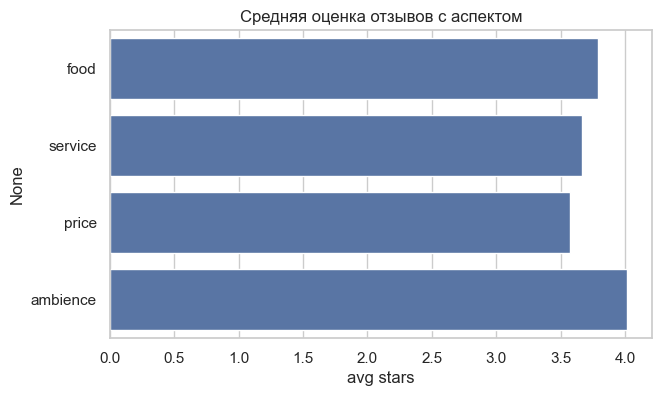

In [32]:
plt.figure(figsize=(7,4))
sns.barplot(x=by_asp["avg_stars"], y=by_asp.index)
plt.title("Средняя оценка отзывов с аспектом")
plt.xlabel("avg stars")
plt.show()

аспекты еда, сервис и цена реально встречаются, и средняя оценка по ним различается, значит разбирать тональность по аспектам имеет смысл.

### Сигнал расхождения текста и оценки
считаем простой лексиконный скор текста и сравниваем со звёздами. сильные расхождения, например злой текст при высокой оценке, это кандидаты в фейки.

In [33]:
POS_LEX = set("great good love amazing best delicious excellent perfect friendly awesome wonderful fantastic".split())
NEG_LEX = set("bad worst terrible awful rude horrible disgusting slow dirty never overpriced disappointing".split())
def lex_score(t):
    w = re.findall(r"[a-z]+", str(t).lower())
    p = sum(x in POS_LEX for x in w)
    n = sum(x in NEG_LEX for x in w)
    return (p - n) / max(p + n, 1)
samp = samp.assign(lex=samp["text"].map(lex_score))
samp["stars_norm"] = (samp["stars"] - 3) / 2
samp["mismatch"] = (samp["stars_norm"] - samp["lex"]).abs()

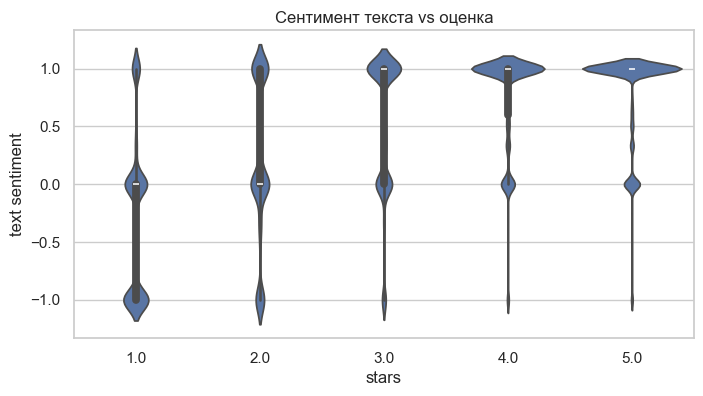

In [34]:
plt.figure(figsize=(8,4))
sns.violinplot(data=samp, x="stars", y="lex")
plt.title("Сентимент текста vs оценка")
plt.ylabel("text sentiment")
plt.show()

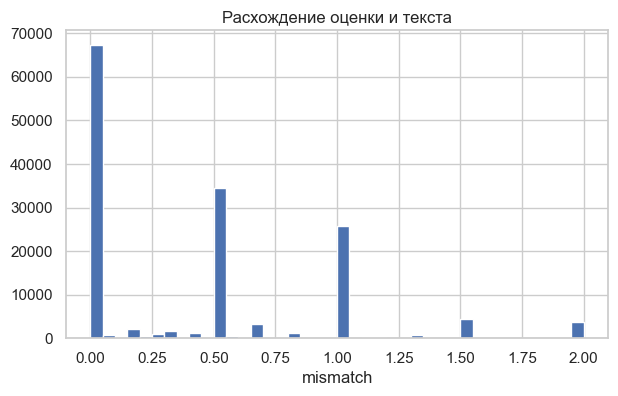

In [35]:
plt.figure(figsize=(7,4))
plt.hist(samp["mismatch"], bins=40)
plt.title("Расхождение оценки и текста")
plt.xlabel("mismatch")
plt.show()

In [36]:
round((samp["mismatch"] > 1.0).mean(), 3)

np.float64(0.065)

у части отзывов тон текста расходится со звёздами. таких заметная доля, и это сигнал для детектора накруток

### Язык отзывов
модели учим на английском, остальное надо отфильтровать. оцениваем долю на сэмпле.

In [37]:
import langid
lang_samp = samp.sample(4000, random_state=1)
langs = lang_samp["text"].fillna("").map(lambda t: langid.classify(t[:400])[0])
print((langs.value_counts(normalize=True).head(6) * 100).round(2))
print("доля английского", round((langs == "en").mean(), 3))

text
en    99.95
af     0.02
es     0.02
Name: proportion, dtype: float64
доля английского 1.0


почти все отзывы английские, доля других языков очень маленькая. их можно просто отфильтровать на препроцессинге.

### Типсы
у типсов нет рейтинга, это объект для инференса обученной моделью. сравниваем их длину с отзывами.

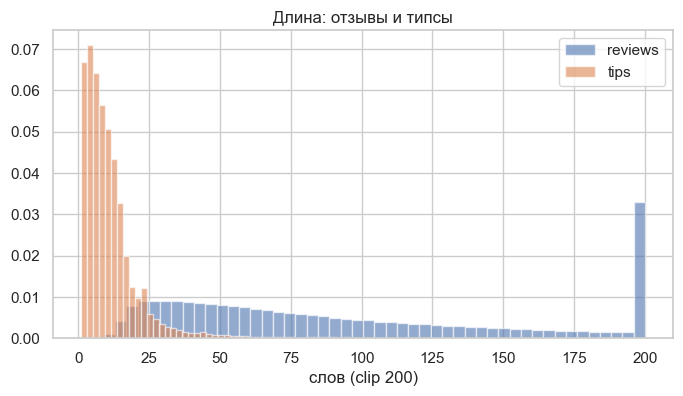

типсов без оценки 91803 медиана длины 9


In [38]:
if len(tips):
    tips["n_words"] = tips["text"].str.split().map(len)
    plt.figure(figsize=(8,4))
    plt.hist(reviews["n_words"].clip(upper=200), bins=50, alpha=0.6, density=True, label="reviews")
    plt.hist(tips["n_words"].clip(upper=200), bins=50, alpha=0.6, density=True, label="tips")
    plt.legend()
    plt.title("Длина: отзывы и типсы")
    plt.xlabel("слов (clip 200)")
    plt.show()
    print("типсов без оценки", len(tips), "медиана длины", int(tips["n_words"].median()))
else:
    print("tips.parquet пуст")

типсы заметно короче отзывов и без оценки. на них потом можно прогнать обученную модель и проставить тональность.

## Качество данных
пропуски, дубликаты, повторные визиты и удалённые юзеры

In [39]:
print("пропуски по таблицам:")
for name, df in [("business", business), ("reviews", reviews), ("users", users)]:
    miss = df.isna().mean()
    miss = miss[miss > 0]
    print(name, dict(miss.round(3)) if len(miss) else "нет пропусков")
dup_rev = reviews.duplicated(subset=["review_id"]).sum()
dup_pair = reviews.duplicated(subset=["user_id", "business_id"]).sum()
missing_users = (~reviews["user_id"].isin(users["user_id"])).mean()
print("дубликаты review_id", dup_rev)
print("повторные пары user-business", dup_pair)
print("отзывы от удалённых юзеров", round(missing_users, 3))

пропуски по таблицам:
business {'categories': np.float64(0.001), 'price_range': np.float64(0.441)}
reviews нет пропусков
users нет пропусков


дубликаты review_id 0
повторные пары user-business 26680
отзывы от удалённых юзеров 0.0


## Выводы

Рекомендатель: внимание на Yelp распределено очень неравномерно, большинство мест и юзеров с единичными отзывами, поэтому нужны индивидуальные обучаемые векторы вкусов, а простые смещения добрый юзер или хорошее место уже дают честный baseline.

Анализ отзывов: длинные отзывы есть и у довольных и у недовольных, а упоминания сервиса тянут оценку вниз сильнее чем еда. отсюда смысл аспектной тональности. часть отзывов расходится по тону со звездами, это основа для детектора накруток, а тысячи типсов без оценки ждут модель.